# Métricas GD e IGD

Na teoria, **GD (Generational Distance)** e **IGD (Inverted Generational Distance)** são definidos em relação à *verdadeira* fronteira de Pareto, mas na prática quase nunca conhecemos essa fronteira real para problemas reais.

---

## Definições

* **GD**: mede quão perto o conjunto obtido $A$ está da fronteira de Pareto verdadeira $P^*$.

$$
GD(A,P^*) = \frac{1}{|A|} \left( \sum_{a \in A} d(a,P^*)^p \right)^{1/p}
$$

onde $d(a,P^*)$ é a distância mínima do ponto $a$ até algum ponto de $P^*$.

* **IGD**: mede quão bem $A$ cobre $P^*$.

$$
IGD(A,P^*) = \frac{1}{|P^*|} \sum_{p \in P^*} d(p,A)
$$

👉 O GD foca na **convergência**, o IGD na **diversidade/cobertura**.


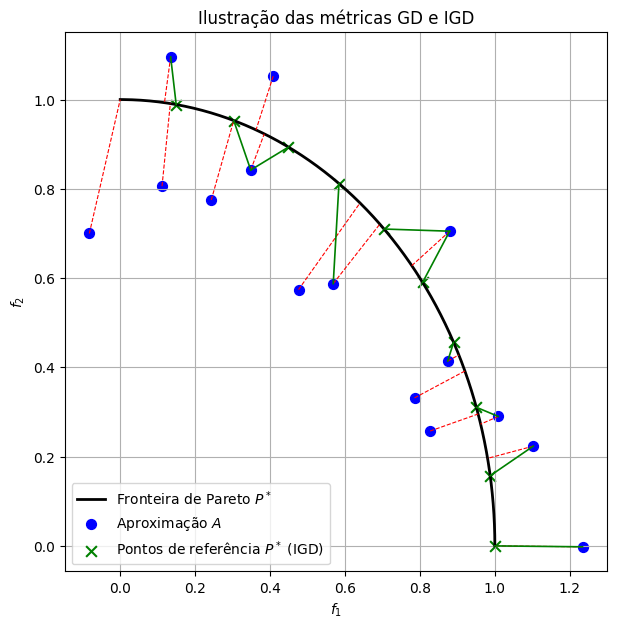

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# --- Funções auxiliares ---
def generate_true_pareto_front(num_points=100):
    """Gera uma fronteira de Pareto em 2D (curva do DTLZ2 simplificada)."""
    theta = np.linspace(0, np.pi/2, num_points)
    x = np.cos(theta)
    y = np.sin(theta)
    return np.vstack((x, y)).T

def generate_approximation(num_points=20, noise=0.1):
    """Gera pontos aproximados próximos da fronteira de Pareto."""
    pf = generate_true_pareto_front(num_points)
    approx = pf + np.random.normal(0, noise, pf.shape)
    return approx

def euclidean_distance(point, set_points):
    """Calcula a distância euclidiana mínima de um ponto para um conjunto."""
    return np.min(np.linalg.norm(set_points - point, axis=1))

# --- Gerar dados ---
pareto_front = generate_true_pareto_front(200)
approximation = generate_approximation(15, noise=0.15)

# Amostragem da fronteira para ilustrar IGD
sample_pf = pareto_front[::20]

# --- Calcular GD (distâncias da aproximação ao PF) ---
gd_distances = [euclidean_distance(a, pareto_front) for a in approximation]

# --- Calcular IGD (distâncias do PF à aproximação) ---
igd_distances = [euclidean_distance(p, approximation) for p in sample_pf]

# --- Plot ---
fig, ax = plt.subplots(figsize=(7, 7))

# Fronteira de Pareto verdadeira
ax.plot(pareto_front[:, 0], pareto_front[:, 1], 'k-', lw=2, label="Fronteira de Pareto $P^*$")

# Pontos da aproximação
ax.scatter(approximation[:, 0], approximation[:, 1], c='blue', s=50, label="Aproximação $A$")

# Pontos amostrados da fronteira (para IGD)
ax.scatter(sample_pf[:, 0], sample_pf[:, 1], c='green', s=60, marker='x', label="Pontos de referência $P^*$ (IGD)")

# Linhas GD (A -> P*)
for a in approximation:
    nearest = pareto_front[np.argmin(np.linalg.norm(pareto_front - a, axis=1))]
    ax.plot([a[0], nearest[0]], [a[1], nearest[1]], 'r--', lw=0.8)

# Linhas IGD (P* -> A)
for p in sample_pf:
    nearest = approximation[np.argmin(np.linalg.norm(approximation - p, axis=1))]
    ax.plot([p[0], nearest[0]], [p[1], nearest[1]], 'g-', lw=1.2)

# Estética
ax.set_title("Ilustração das métricas GD e IGD")
ax.set_xlabel("$f_1$")
ax.set_ylabel("$f_2$")
ax.legend(loc="lower left")
ax.grid(True)
plt.show()


## Problema prático

Na maioria dos problemas reais, $P^*$ é **desconhecida** ou impossível de obter analiticamente.
Então, como calcular GD/IGD?

---

## Estratégias usadas na literatura

### 1. **Aproximação por conjunto de referência**

* Executa-se um conjunto **amplo de algoritmos distintos** (ou muitas execuções de um mesmo algoritmo).
* Reúne-se todas as soluções não dominadas encontradas.
* Aplica-se uma filtragem para obter um **conjunto de referência aproximado**, considerado como proxy de $P^*$.
* Esse conjunto é chamado de **PF\_approx** ou **fronteira de Pareto aproximada**.
* GD e IGD são então calculados em relação a esse conjunto.

👉 Esse é o **procedimento mais comum** em artigos práticos de EMO (Evolutionary Multiobjective Optimization).

---

### 2. **Benchmark com fronteira conhecida**

* Em problemas artificiais como DTLZ, ZDT, WFG, a fronteira é conhecida analiticamente.
* Nesse caso, usa-se diretamente a formulação exata de $P^*$.

---

### 3. **Amostragem via métodos matemáticos**

* Para problemas contínuos mas sem forma fechada, pode-se usar técnicas de **otimização escalar repetida** (ε-constraint, weighted sum, Tchebycheff, etc.) para amostrar pontos próximos do PF.
* Usado menos frequentemente porque é caro e também só aproxima.

---

### 4. **Variantes métricas independentes de PF**

* Quando não é viável construir $PF_{approx}$, alguns trabalhos substituem GD/IGD por métricas alternativas como **Hypervolume (HV)**, que não precisa do PF real.
* Isso é comum em artigos recentes porque HV evita a dependência de um “oráculo” externo.

---

## Implicações práticas

* Em benchmarks → usa-se a fronteira real conhecida (DTLZ, ZDT, etc.).
* Em problemas reais → quase sempre GD/IGD são calculados **contra uma fronteira de referência obtida via união de execuções/algoritmos**.
* Por isso, é importante reportar **como o PF de referência foi construído** no artigo, pois isso impacta diretamente o valor de GD/IGD.

---

📌 **Resumo**:
Quando não se sabe a fronteira real, a literatura usa um **conjunto de referência aproximado**, construído a partir da **união de soluções não dominadas** geradas por vários algoritmos/execuções. Esse conjunto substitui $P^*$ para o cálculo de GD/IGD.